In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics


Data collection and processing

In [20]:
gold_data = pd.read_csv("/content/sample_data/gld_price_data.csv")


In [21]:
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [22]:
gold_data.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [23]:
gold_data.shape

(2290, 6)

In [24]:
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


In [25]:
gold_data.isnull().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


In [26]:
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


Correlation

In [27]:
correlation = gold_data.corr(numeric_only=True)

<Axes: >

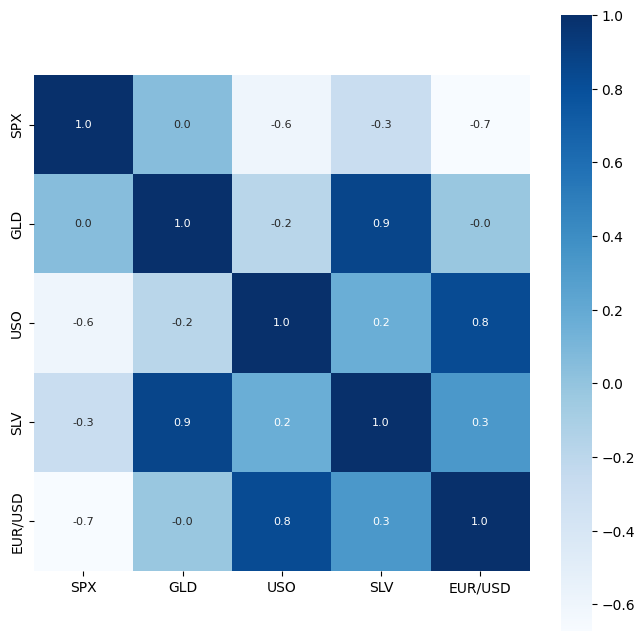

In [28]:
# constructing heatmap to understand correlation
plt.figure(figsize = (8,8))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues' )

In [29]:
# correlation values of GLD
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


/tmp/ipykernel_384/3017478376.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gold_data['GLD'],color='green')


<Axes: xlabel='GLD', ylabel='Density'>

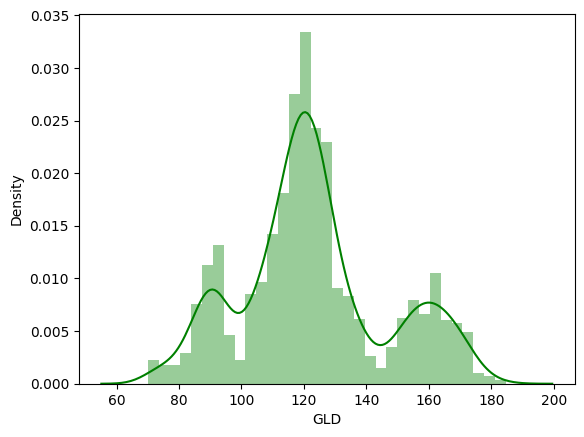

In [30]:
# checking the distribution of the gold price
sns.distplot(gold_data['GLD'],color='green')

Splitting the features and target

In [31]:
x = gold_data.drop(['Date','GLD'],axis=1)
y = gold_data['GLD']

print(x)
print(y)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]
0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


Test and Train split

In [32]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=2)

Model Training

In [33]:
from os import X_OK
regressor = RandomForestRegressor(n_estimators=100)
regressor.fit(x_train,y_train)

RandomForestRegressor()

In [34]:
# prediction on test data
test_data_prediction = regressor.predict(x_test)
print(test_data_prediction)

[168.56649949  82.3096996  115.84580016 127.71110091 120.73860119
 154.81549806 150.04789804 126.10420034 117.42779885 126.10570086
 116.79620087 172.11510116 141.73789844 168.16459853 115.15609999
 117.56390036 141.55100281 170.39020088 160.01810236 161.53879891
 155.17660045 125.03370022 176.1403999  157.59130341 125.26080013
  93.86039975  77.5391004  120.67980006 119.12529927 167.5105
  88.23180074 125.01340019  91.06280048 117.58230065 121.08899893
 135.93030098 115.5464013  115.17000076 147.34459927 107.30520118
 104.58020255  87.18049805 126.45870009 117.66749963 153.01959917
 119.63640023 108.31229979 107.88139774  93.15480044 127.14019767
  74.37370059 113.73389953 121.52290025 111.29649883 118.8241991
 120.46319952 159.17129986 166.95380123 146.97369688  85.92919909
  94.41760047  86.84369921  90.46870019 118.95690082 126.51580106
 127.68799989 170.25019954 122.25059937 117.36649885  98.61120039
 168.6416011  142.95629859 132.15140247 121.22820228 121.43269942
 119.80780076 1

In [37]:
# R squarred error

error_score = metrics.r2_score(y_test, test_data_prediction)
print("R square error: ",error_score)

R square error:  0.9898940292129753


Compare the actual and predicted values in a plot

In [38]:
y_test = list(y_test)


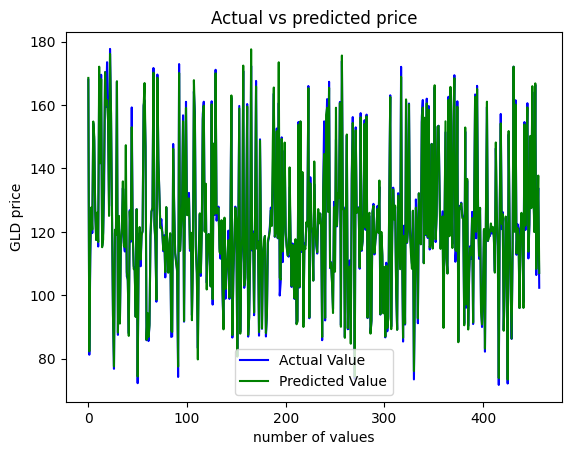

In [41]:
plt.plot(y_test,color='blue',label='Actual Value')
plt.plot(test_data_prediction,color='green',label='Predicted Value')
plt.title("Actual vs predicted price")
plt.xlabel('number of values')
plt.ylabel('GLD price')
plt.legend()
plt.show()